In [41]:
#Step - 1 : Import libraries
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import mean_squared_error,r2_score

#Step - 2 : load the dataset(StudentDataForDataAnalysis.xlsx -> excel file)
df=pd.read_excel("C:/Users/Admin/Desktop/JN/Internship Task/StudentDataForDataAnalysis.xlsx")



#Step - 3 : Select Important Columns 
df=df[['StudentID','CurrentCPI','CurrentSPI','CurrentSemester','CityName']]
df.head(5)


#Step - 4 : Checking Shap , datatype and null values
print("Shape of Dataset:", df.shape)
print("Data Types:",df.dtypes)
print("Null Values:",df.isnull().sum())



Shape of Dataset: (376, 5)
Data Types: StudentID            int64
CurrentCPI         float64
CurrentSPI         float64
CurrentSemester      int64
CityName            object
dtype: object
Null Values: StudentID            0
CurrentCPI           9
CurrentSPI           9
CurrentSemester      0
CityName           235
dtype: int64


In [42]:
# Step - 5 : Handling Missing values
df['CityName']=df['CityName'].fillna(df['CityName'].mode()[0])
df['CurrentCPI']=df['CurrentCPI'].fillna(df['CurrentCPI'].mean())
df['CurrentSPI']=df['CurrentSPI'].fillna(df['CurrentSPI'].mean())
print(df.isnull().sum())

StudentID          0
CurrentCPI         0
CurrentSPI         0
CurrentSemester    0
CityName           0
dtype: int64


In [43]:
# Step - 6 : Check dupliacte records if there any
print("Duplicate records: ",df.duplicated().sum())
df=df.drop_duplicates()
print("After removing duplicates:",df.shape)

Duplicate records:  0
After removing duplicates: (376, 5)


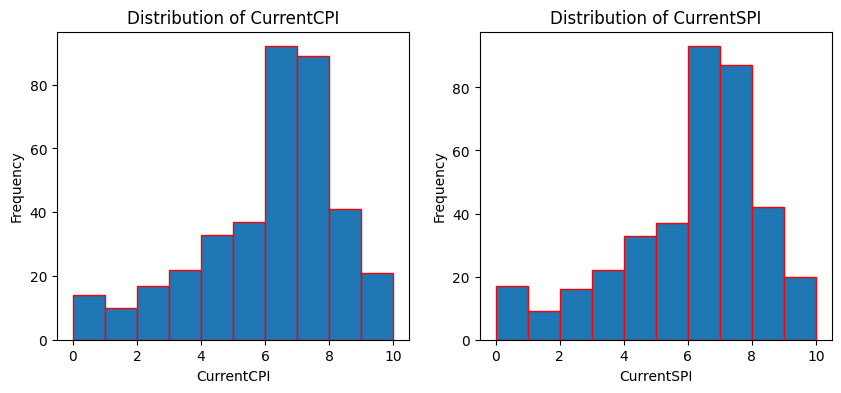

'It shows most of student have CPI and SPI in between 5 and 8 so that majority are avg to good perfomers.\nvery few are extremes'

In [44]:
# Step - 7 : Plot CPI and SPI Histograms

#CPI Histogram
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['CurrentCPI'],bins=10,edgecolor="Red")
plt.title("Distribution of CurrentCPI")
plt.xlabel("CurrentCPI")
plt.ylabel("Frequency")


#SPI Histogram
#plt.subplot(row,column,position)
plt.subplot(1,2,2)
plt.hist(df['CurrentSPI'],bins=10,edgecolor="Red")
plt.title("Distribution of CurrentSPI")
plt.xlabel("CurrentSPI")
plt.ylabel("Frequency")

plt.show()

'''It shows most of student have CPI and SPI in between 5 and 8 so that majority are avg 
to good perfomers.very few are extremes'''

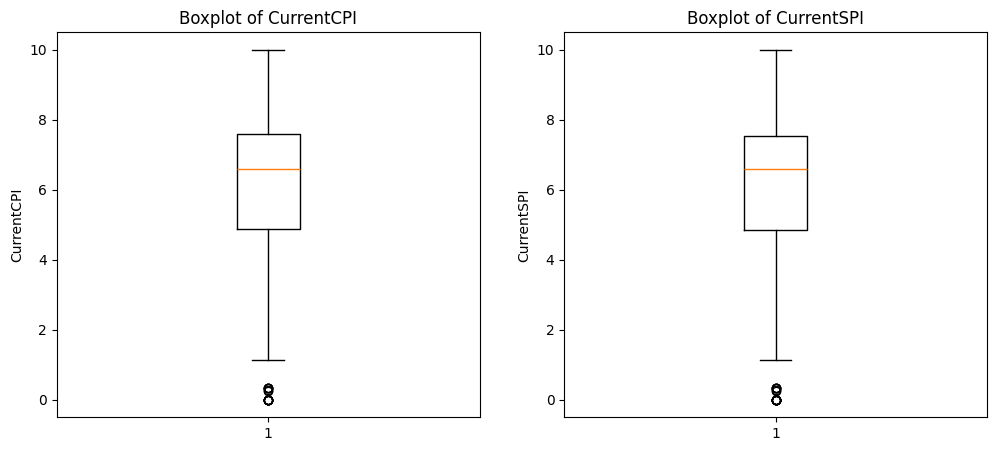

'\nmost of student have CPI and SPI b/w 5 and 7.5 arround ,with median is 6-7 around and a some are outliers.\n'

In [45]:
# Step - 8 : Plot Boxplot of CPI and SPI

#CPI Boxplot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.boxplot(df['CurrentCPI'])
plt.title("Boxplot of CurrentCPI")
plt.ylabel("CurrentCPI")

#SPI Boxplot
plt.subplot(1,2,2)
plt.boxplot(df['CurrentSPI'])
plt.title("Boxplot of CurrentSPI")
plt.ylabel("CurrentSPI")

plt.show()

'''
most of student have CPI and SPI b/w 5 and 7.5 arround ,with median is 6-7 around and
a some are outliers.
'''

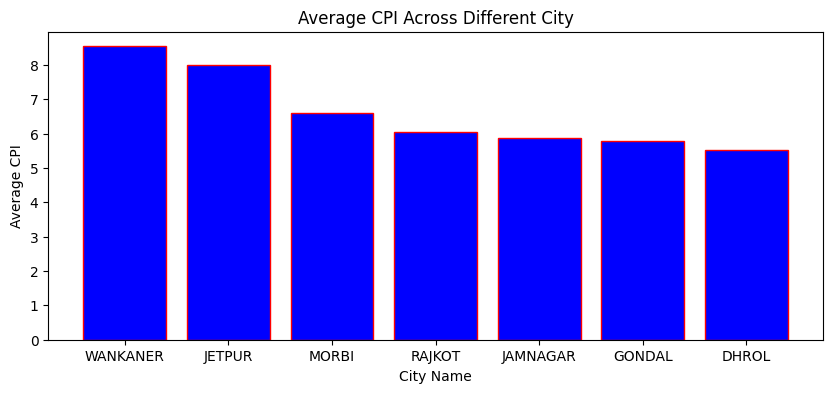

'\nWankaner and jetpur having the higher avg CPI and Dhorl having lower CPI .\n'

In [46]:
# Step - 9 : Avg CPI across cities
City_avg=df.groupby('CityName')['CurrentCPI'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
plt.bar(City_avg.index,City_avg.values,color='Blue', edgecolor='Red')
plt.title("Average CPI Across Different City")
plt.xlabel("City Name")
plt.ylabel("Average CPI")
plt.show()

'''
Wankaner and jetpur having the higher avg CPI and Dhorl having lower CPI .
'''

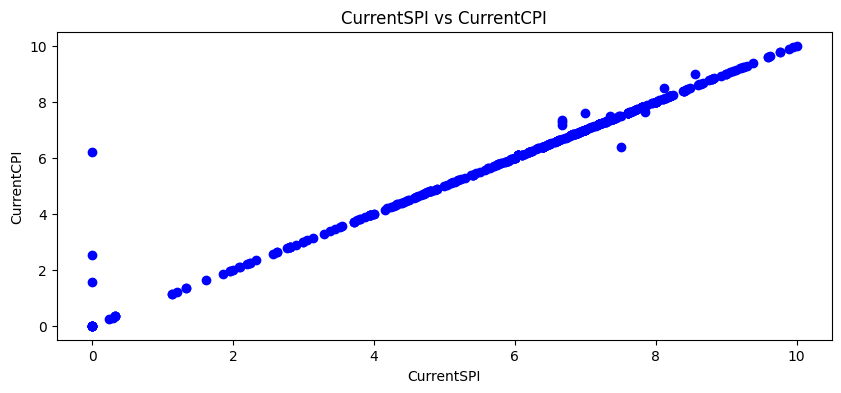

'\nSPI increases CPI also Increase it shows the strong positive reationship between 2 numerical columns\n(SPI and CPI) and it identify the CPI and SPI is realted to each other\n'

In [47]:
# Step - 10 : CPI vs SPI scatter plot
plt.figure(figsize=(10,4))
plt.scatter(df['CurrentSPI'] , df['CurrentCPI'], color='blue')
plt.title("CurrentSPI vs CurrentCPI")
plt.xlabel("CurrentSPI")
plt.ylabel("CurrentCPI")
plt.show()

'''
SPI increases CPI also Increase it shows the strong positive reationship between 2 numerical columns
(SPI and CPI) and it identify the CPI and SPI is realted to each other
'''

     StudentID  CurrentCPI  CurrentSemester CityName
127     839490       10.00                4   RAJKOT
248     854394        9.95                4   RAJKOT
312     858738        9.89                4   RAJKOT
83      831204        9.76                4   RAJKOT
157     844746        9.76                4   RAJKOT
278     855822        9.62                4   RAJKOT
266     855072        9.60                4   RAJKOT
350     862830        9.60                4    MORBI
265     855042        9.38                4   RAJKOT
1       805182        9.29                4   RAJKOT


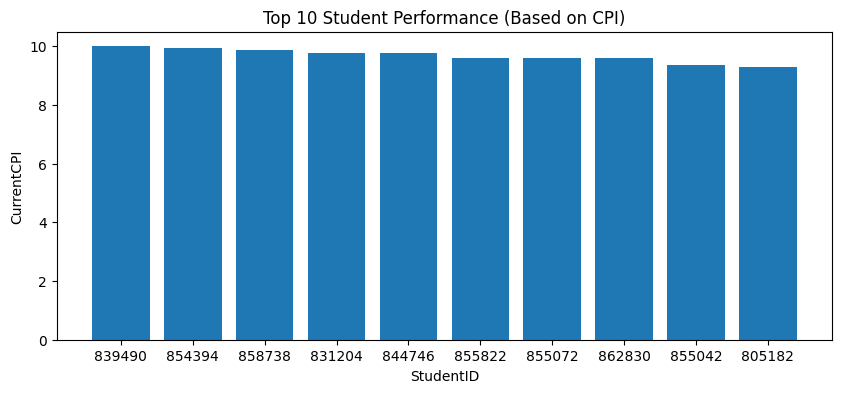

     StudentID  CurrentCPI  CurrentSemester CityName
55      826644        0.00                4   RAJKOT
115     837714        0.00                4   RAJKOT
172     846624        0.00                4   RAJKOT
210     851352        0.00                4   RAJKOT
236     853554        0.00                4   RAJKOT
258     854706        0.00                4   RAJKOT
309     858558        0.00                4   RAJKOT
320     859140        0.00                4   RAJKOT
240     853848        0.24                4   RAJKOT
73      829020        0.29                4   RAJKOT


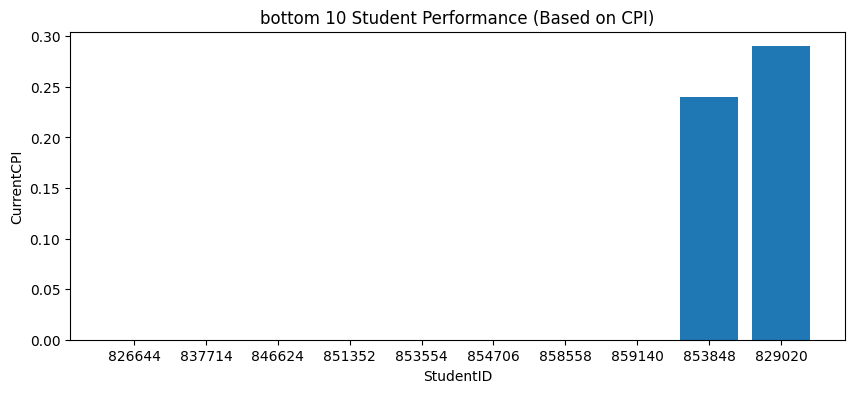

In [48]:
# Step - 11 : Top 10 student's performance  &  Bottom 10 student's performance
#Top 10 student's perfomace
top=df.nlargest(10,'CurrentCPI')[['StudentID','CurrentCPI','CurrentSemester','CityName']]
print(top)

#visualize top 10 student perfomance using matplotlib
top=df.nlargest(10, 'CurrentCPI')
plt.figure(figsize=(10,4))
plt.bar(top['StudentID'].astype(str), top['CurrentCPI'])
plt.title("Top 10 Student Performance (Based on CPI)")
plt.xlabel("StudentID")
plt.ylabel("CurrentCPI")
plt.show()


#bottom 10 student's performance
bottom=df.nsmallest(10,'CurrentCPI')[['StudentID','CurrentCPI','CurrentSemester','CityName']]
print(bottom)

#visualize botom 10 student perfomance using matplotlib
bottom=df.nsmallest(10, 'CurrentCPI')
plt.figure(figsize=(10,4))
plt.bar(bottom['StudentID'].astype(str), bottom['CurrentCPI'])
plt.title("bottom 10 Student Performance (Based on CPI)")
plt.xlabel("StudentID")
plt.ylabel("CurrentCPI")
plt.show()


In [49]:
# Step - 12 : Descriptive Statistics for CPI and SPI
print("Current CPI:")
print(df['CurrentCPI'].describe())
print("Skewness:",df['CurrentCPI'].skew())
print("\n")
print("CurrentSPI:")
print(df['CurrentSPI'].describe())
print("Skewness:",df['CurrentCPI'].skew())

Current CPI:
count    376.000000
mean       6.085123
std        2.181951
min        0.000000
25%        4.890000
50%        6.600000
75%        7.585000
max       10.000000
Name: CurrentCPI, dtype: float64
Skewness: -0.9590354026774941


CurrentSPI:
count    376.000000
mean       6.051635
std        2.224970
min        0.000000
25%        4.847500
50%        6.600000
75%        7.525000
max       10.000000
Name: CurrentSPI, dtype: float64
Skewness: -0.9590354026774941


In [50]:
# Step - 13 : Pearson Correlation b/w CPI and SPI
corr,p_value=stats.pearsonr(df['CurrentCPI'],df['CurrentSPI'])
print("Pearson Correaltion:",corr)
print("P-value:",p_value)

Pearson Correaltion: 0.9864287107819336
P-value: 1.448474972554122e-295


In [51]:
# Step - 14 : perform t-test for CPI between cities

#unique city identify
print(df['CityName'].unique())

#select 2 cities for comaprison
city1=df[df['CityName']=='RAJKOT']['CurrentCPI']
city2=df[df['CityName']=='JETPUR']['CurrentCPI']
t_stat,p_value=stats.ttest_ind(city1,city2)
print("T-Statistic:",t_stat)
print("P-Value:",p_value)

#there is no significance differnce in CPI between Rajkot and Jetpur

['RAJKOT' 'DHROL' 'JETPUR' 'MORBI' 'WANKANER' 'GONDAL' 'JAMNAGAR']
T-Statistic: -0.8732262418744501
P-Value: 0.38315607693713405


In [52]:
# Step - 15 : Outliers detection using IQR
Q1=df['CurrentCPI'].quantile(0.25)
Q3=df['CurrentCPI'].quantile(0.75)
IQR=Q3-Q1
lowerbound=Q1-1.5*IQR
upperbound=Q3+1.5*IQR
outlier=df[(df['CurrentCPI'] < lowerbound) | (df['CurrentCPI'] > upperbound)]
print("No. of  Outliers:",outlier.shape[0])
print(outlier[['StudentID','CurrentCPI']])

No. of  Outliers: 14
     StudentID  CurrentCPI
41      822234        0.33
55      826644        0.00
73      829020        0.29
115     837714        0.00
171     846366        0.33
172     846624        0.00
176     847308        0.33
180     847344        0.33
210     851352        0.00
236     853554        0.00
240     853848        0.24
258     854706        0.00
309     858558        0.00
320     859140        0.00


In [53]:
# Step - 16 : Rank student by CPI and percentile scores
df['rank']=df['CurrentCPI'].rank(ascending=False,method='dense')
df['percentile']=df['CurrentCPI'].rank(pct=True)*100
df[['StudentID','CurrentCPI','rank','percentile']].sort_values('rank').head(10)

,StudentID,CurrentCPI,rank,percentile
127,839490,10.00,1.0,100.000000
248,854394,9.95,2.0,99.734043
312,858738,9.89,3.0,99.468085
157,844746,9.76,4.0,99.069149
83,831204,9.76,4.0,99.069149
278,855822,9.62,5.0,98.670213
350,862830,9.60,6.0,98.271277
266,855072,9.60,6.0,98.271277
265,855042,9.38,7.0,97.872340
1,805182,9.29,8.0,97.606383


# ML model

In [54]:
# Step - 17 : Create Target Label
def target_label(CPI):
    if CPI >=7:
        return 'High'
    elif CPI >=4:
        return 'Medium'
    else:
        return 'Low'
df['target']=df['CurrentCPI'].apply(target_label)
print(df[['CurrentCPI','target']].head(10))

#it convert the CPI into target label for classification ( high , medium , low)

   CurrentCPI  target
0        7.60    High
1        9.29    High
2        4.45  Medium
3        7.20    High
4        4.40  Medium
5        5.50  Medium
6        6.40  Medium
7        2.20     Low
8        6.40  Medium
9        7.60    High


In [55]:
# Step - 18 : Encoding categorical column
le_city=LabelEncoder()
df['City']=le_city.fit_transform(df['CityName'])
#here we convert cityname text data into numeric value because machine learning only undertsand the numerical values.

# CLASSIFICATION MODEL

In [56]:
# Step - 19 : Define target and features for classification
X=df[['CurrentSPI','CurrentSemester','City']]  #Features columns
Y=df['target'] #Target column

# Step - 20 : Split the data into train-test
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42 ,stratify=Y)
print("X_train Shape:",X_train.shape)
print("X_test Shape:",X_test.shape)

X_train Shape: (300, 3)
X_test Shape: (76, 3)


In [57]:
# Step - 21 : Train DecisionTree Classifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,Y_train)
dt_pred=dt_model.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(Y_test,dt_pred))
print("\nDecision Tree Classification Report:")
print(classification_report(Y_test,dt_pred))

Decision Tree Accuracy: 0.9868421052631579

Decision Tree Classification Report:
              precision    recall  f1-score   support

        High       0.97      1.00      0.98        30
         Low       1.00      1.00      1.00        13
      Medium       1.00      0.97      0.98        33

    accuracy                           0.99        76
   macro avg       0.99      0.99      0.99        76
weighted avg       0.99      0.99      0.99        76



# RANDOM FOREST CLASSIFIER MODEL

In [58]:
# Step - 22 : Train Random Forest Classifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,Y_train)
rf_pred=rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(Y_test,rf_pred))
print("\nRandom Forest Classification Report:")
print(classification_report(Y_test,rf_pred))

Random Forest Accuracy: 0.9868421052631579

Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.97      1.00      0.98        30
         Low       1.00      1.00      1.00        13
      Medium       1.00      0.97      0.98        33

    accuracy                           0.99        76
   macro avg       0.99      0.99      0.99        76
weighted avg       0.99      0.99      0.99        76



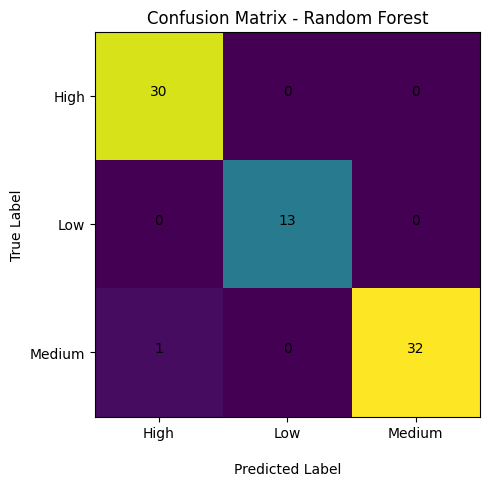

In [59]:
# Step - 23 : confusion matrix for random forest
cm=confusion_matrix(Y_test,rf_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("\nPredicted Label")
plt.ylabel("True Label")
plt.xticks([0,1,2],['High','Low','Medium'])
plt.yticks([0,1,2],['High','Low','Medium'])

for i in range(3):
    for j in range(3):
        plt.text(j,i,cm[i,j],ha='center',color='black')
plt.show()

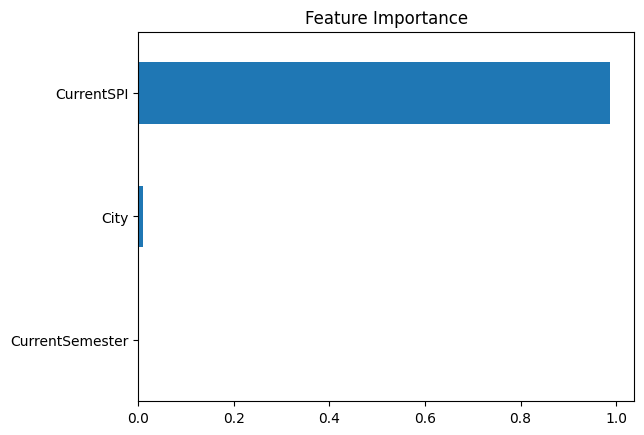

In [60]:
# Step - 24 : Feature Importance 
feature_imp=pd.Series(rf_model.feature_importances_,index=X.columns)
feature_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

#  REGRESSION MODEL (LINEAR REGRESSION)

In [61]:
# Step - 25 : Define freatures and target variabled for Regression
X_reg=df[['CurrentSPI','CurrentSemester','City']]
Y_reg=df['CurrentCPI']


# Step - 26 : Split the dataset into train-test
X_train_reg,X_test_reg,Y_train_reg,Y_test_reg=train_test_split(X_reg,Y_reg,test_size=0.2,random_state=42)

In [62]:
# Step - 27 : Train Linear Regression Model
reg_model=LinearRegression()
reg_model.fit(X_train_reg,Y_train_reg)
Y_pred_reg=reg_model.predict(X_test_reg)


In [63]:
# Step - 28 : Evaluate Regression model
rmse=np.sqrt(mean_squared_error(Y_test_reg,Y_pred_reg))
r2=r2_score(Y_test_reg,Y_pred_reg)
print("RMSE:",rmse)
print("R2 Score:",r2)

#RMSE tells avg prediction error and R2 score tell how well the model fit the data(accuracy)

RMSE: 0.7006751143286624
R2 Score: 0.8970196136287261


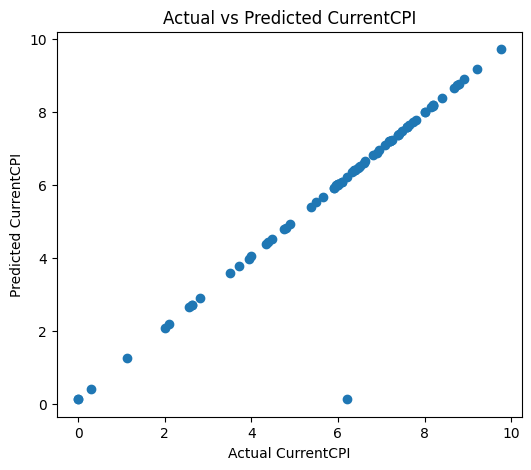

In [64]:
# Step - 29 : Plot actual vs predicted CPI
plt.figure(figsize=(6,5))
plt.scatter(Y_test_reg,Y_pred_reg)
plt.xlabel("Actual CurrentCPI")
plt.ylabel("Predicted CurrentCPI")
plt.title("Actual vs Predicted CurrentCPI")
plt.show()

#most of points are on straight line so that it shows model predict CPI very accurately.